In [1]:
import os
os.environ['KERAS_BACKEND'] = "tensorflow"
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
import keras
import keras.layers as lay
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

2025-09-01 21:39:43.156224: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756762783.185397 3082222 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756762783.194980 3082222 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756762783.218997 3082222 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756762783.219022 3082222 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756762783.219025 3082222 computation_placer.cc:177] computation placer alr

In [2]:
(trainx,trainy),(valx,valy)= keras.datasets.imdb.load_data(num_words=10000)
trainx = keras.preprocessing.sequence.pad_sequences(trainx,maxlen=500)
valx = keras.preprocessing.sequence.pad_sequences(valx,maxlen=500)
train = tf.data.Dataset.from_tensor_slices((trainx,trainy)).cache().shuffle(2**10).batch(2**11).prefetch(tf.data.AUTOTUNE)
val = tf.data.Dataset.from_tensor_slices((valx,valy)).cache().shuffle(2**10).batch(2**11).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1756762791.947628 3082222 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10262 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:04:00.0, compute capability: 8.6


In [3]:
model = keras.Sequential([
    lay.InputLayer((500,)),
    lay.Embedding(input_dim=10000,output_dim=8),
    lay.GRU(2**5,activation='tanh'),
    lay.Dense(1,activation='sigmoid')
])
model.summary()
model.compile(
    optimizer=keras.optimizers.Adam(1e-3,.99),
    loss=keras.losses.BinaryCrossentropy('loss'),
    metrics=[keras.metrics.BinaryAccuracy('acc')]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 8)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,065 (328.38 KB)

 Trainable params: 84,065 (328.38 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
hist = model.fit(
    train,
    epochs=100,
    validation_data=val,
)

Epoch 1/100


/home/villeneve/venv311/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:789: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
I0000 00:00:1756762796.147933 3082272 cuda_dnn.cc:529] Loaded cuDNN version 90300


13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/step - acc: 0.5116 - loss: 0.6924 - val_acc: 0.6206 - val_loss: 0.6908
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - acc: 0.6232 - loss: 0.6884 - val_acc: 0.6183 - val_loss: 0.6857
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - acc: 0.6686 - loss: 0.6806 - val_acc: 0.6486 - val_loss: 0.6766
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - acc: 0.6787 - loss: 0.6676 - val_acc: 0.6558 - val_loss: 0.6621
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - acc: 0.7038 - loss: 0.6463 - val_acc: 0.6811 - val_loss: 0.6381
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - acc: 0.7216 - loss: 0.6108 - val_acc: 0.7054 - val_loss: 0.5945
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - acc: 0.7496 - loss: 0.5422 - val_acc: 0.7551 - val_loss: 0.5002
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - acc: 0.7820 - loss: 0.4634 - val_acc: 0.7858 - val_loss: 0.4649
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - acc: 

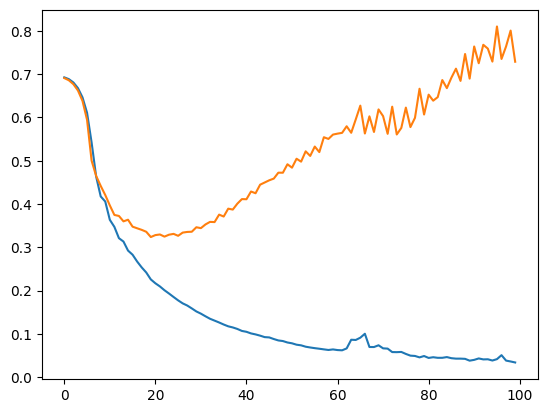

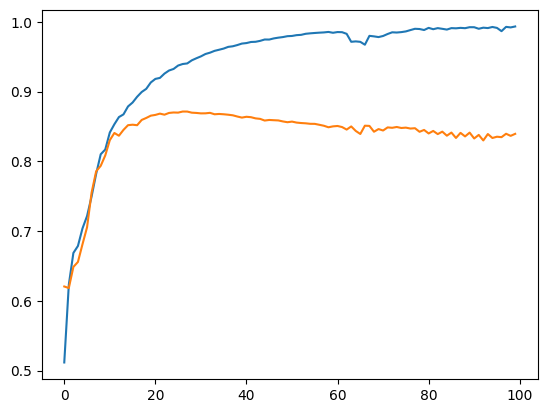

In [ ]:
sns.lineplot(hist.history['loss'])
sns.lineplot(hist.history['val_loss'])
plt.show()

plt.plot(hist.history['acc'])
plt.plot(hist.history['val_acc'])
plt.show()